# Multi-Task WiFi CSI Sensing — Notebook

Transformer-based multi-task model for human activity recognition, fall detection,
and subject identification from WiFi Channel State Information (CSI).

Dataset: [Kaggle: geninhu/csi-dataset](https://www.kaggle.com/datasets/geninhu/csi-dataset)

Sections:
1. Setup & data download
2. Exploration & EDA
3. Data preparation (windowing + splits)
4. Model definition
5. Training (50 epochs)
6. Test evaluation
7. Experiment 1: Single-task baselines
8. Experiment 2: Loss weighting ablation
9. Experiment 3: Cross-session generalization
10. Experiment 4: Gradient Reversal rescue
11. Experiment 5: t-SNE visualization
12. Save artifacts

## 1. Setup & data download

In [1]:
# all imports for the notebook
import os
import math
import copy
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

### REMOVE BEFORE PUSH — Kaggle download (Colab-only)

This cell downloads the dataset using your Kaggle API token. **The token is a
secret — replace `YOUR_KAGGLE_TOKEN_HERE` with your own and remove this cell
before pushing to GitHub.**

Get a token at https://kaggle.com/settings/api → Create New Token.

In [2]:
# REMOVE BEFORE PUSH - contains API token
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_02d0aac251d350f12d7ec9114637e3d9'

!pip install -q --upgrade kaggle
!kaggle datasets download -d geninhu/csi-dataset
!unzip -q csi-dataset.zip -d csi_data
!ls csi_data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 15.2 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/geninhu/csi-dataset
License(s): unknown
100% 1.34G/1.34G [00:13<00:00, 108MB/s] 

data


## 2. Exploration & EDA

### REMOVE BEFORE PUSH — exploration cells

The next 3 cells are one-time exploration (folder structure, file listing,
sample inspection). They informed our design decisions but aren't needed for
reproducing results. Mark these for removal before pushing if you want a
cleaner final notebook.

In [3]:
for root, dirs, files in os.walk("csi_data"):
    level = root.replace("csi_data", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:5]:  # first 5 files per folder
        print(f"{indent}  {f}")
    if len(files) > 5:
        print(f"{indent}  ... +{len(files)-5} more")

csi_data/
  data/
    CSI_data_S25.npz
    CSI_data_S24.npz
    CSI_data_S18.npz
    CSI_data_S12.npz
    CSI_data_S08.npz
    ... +25 more
    output/
      label/
        CSI_label_S11.npz
        CSI_label_S10.npz
        CSI_label_S01.npz
        CSI_label_S09.npz
        CSI_label_S05.npz
        ... +25 more


In [4]:
npz_files = sorted([os.path.join(r, f) for r, d, fs in os.walk("csi_data") for f in fs if f.endswith(".npz")])

print(f"All {len(npz_files)} files:")
for p in npz_files:
    print(" ", os.path.basename(p))

# check shapes across files - are they all same size? different?
print("\nShapes across files:")
shapes = []
for p in npz_files[:15]:
    with np.load(p) as d:
        s = d['arr_0'].shape
        shapes.append(s)
        print(f"  {os.path.basename(p)}: {s}")

# also check if there's any non-.npz file (metadata, readme)
print("\nNon-npz files in dataset:")
for root, dirs, files in os.walk("csi_data"):
    for f in files:
        if not f.endswith(".npz"):
            print(" ", os.path.join(root, f))

# peek at the actual values
arr = np.load(npz_files[0])['arr_0']
print(f"\nSample values from {os.path.basename(npz_files[0])}:")
print(f"  min={arr.min():.3f}, max={arr.max():.3f}, mean={arr.mean():.3f}")
print(f"  first row (first 10 values): {arr[0, :10]}")
print(f"  last column unique values (could be label?): {np.unique(arr[:, -1])[:20]}")

All 60 files:
  CSI_data_S01.npz
  CSI_data_S02.npz
  CSI_data_S03.npz
  CSI_data_S04.npz
  CSI_data_S05.npz
  CSI_data_S06.npz
  CSI_data_S07.npz
  CSI_data_S08.npz
  CSI_data_S09.npz
  CSI_data_S10.npz
  CSI_data_S11.npz
  CSI_data_S12.npz
  CSI_data_S13.npz
  CSI_data_S14.npz
  CSI_data_S15.npz
  CSI_data_S16.npz
  CSI_data_S17.npz
  CSI_data_S18.npz
  CSI_data_S19.npz
  CSI_data_S20.npz
  CSI_data_S21.npz
  CSI_data_S22.npz
  CSI_data_S23.npz
  CSI_data_S24.npz
  CSI_data_S25.npz
  CSI_data_S26.npz
  CSI_data_S27.npz
  CSI_data_S28.npz
  CSI_data_S29.npz
  CSI_data_S30.npz
  CSI_label_S01.npz
  CSI_label_S02.npz
  CSI_label_S03.npz
  CSI_label_S04.npz
  CSI_label_S05.npz
  CSI_label_S06.npz
  CSI_label_S07.npz
  CSI_label_S08.npz
  CSI_label_S09.npz
  CSI_label_S10.npz
  CSI_label_S11.npz
  CSI_label_S12.npz
  CSI_label_S13.npz
  CSI_label_S14.npz
  CSI_label_S15.npz
  CSI_label_S16.npz
  CSI_label_S17.npz
  CSI_label_S18.npz
  CSI_label_S19.npz
  CSI_label_S20.npz
  CSI_label_S21.

### Inspect labels in session 1

In [5]:
# both CSI data and labels live in csi_data/data/
BASE = "csi_data/data"

# load session 1
csi = np.load(f"{BASE}/CSI_data_S01.npz")['arr_0']
lab = np.load(f"{BASE}/output/label/CSI_label_S01.npz")['arr_0']

print(f"CSI shape: {csi.shape}, dtype: {csi.dtype}")
print(f"Label shape: {lab.shape}, dtype: {lab.dtype}")
print(f"All unique labels ({len(np.unique(lab))}):")
for u in np.unique(lab):
    print(f"  {u}")

print(f"\nLabel counts (session 1):")
unique, counts = np.unique(lab, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u:<40s}: {c:>8d} packets ({100*c/len(lab):.1f}%)")

CSI shape: (374584, 90), dtype: float32
Label shape: (374584,), dtype: <U35
All unique labels (10):
  falling_down_from_sitting_position
  falling_down_from_standing_position
  lying
  pick_a_pen_from_the_ground
  sitting
  sitting_down
  stand_still
  standing up
  turning
  walking

Label counts (session 1):
  falling_down_from_sitting_position      :    25482 packets (6.8%)
  falling_down_from_standing_position     :    25502 packets (6.8%)
  lying                                   :    51026 packets (13.6%)
  pick_a_pen_from_the_ground              :    27870 packets (7.4%)
  sitting                                 :    51016 packets (13.6%)
  sitting_down                            :    20435 packets (5.5%)
  stand_still                             :    51021 packets (13.6%)
  standing up                             :    20414 packets (5.4%)
  turning                                 :    50937 packets (13.6%)
  walking                                 :    50881 packets (13.6%)


## 3. Data preparation

10 activity classes. Note that `'standing up'` has a space (dataset typo) — keeping
it as-is so the lookup matches. Window size 500 packets (~1 sec at typical CSI
sampling rate), stride 250 (50% overlap), keeping only "pure" windows where
all packets share the same activity label.

In [6]:
# config
WINDOW_SIZE = 500
STRIDE = 250
N_SESSIONS = 30

# note: 'standing up' has a space - took me a while to figure out why class 7 was empty
ACTIVITY_CLASSES = [
    'falling_down_from_sitting_position',
    'falling_down_from_standing_position',
    'lying',
    'pick_a_pen_from_the_ground',
    'sitting',
    'sitting_down',
    'stand_still',
    'standing up',
    'turning',
    'walking',
]
ACT_TO_IDX = {c: i for i, c in enumerate(ACTIVITY_CLASSES)}
FALL_CLASSES = {'falling_down_from_sitting_position', 'falling_down_from_standing_position'}

print("Activity classes:", len(ACTIVITY_CLASSES))
print("Fall classes:", FALL_CLASSES)

Activity classes: 10
Fall classes: {'falling_down_from_sitting_position', 'falling_down_from_standing_position'}


### Windowing function

In [7]:
def make_windows(csi, labels, window=WINDOW_SIZE, stride=STRIDE):
    # slide a window across packets; only keep pure-label windows
    X, y_act, y_fall = [], [], []
    n = len(csi)
    for start in range(0, n - window + 1, stride):
        end = start + window
        window_labels = labels[start:end]
        unique_labels = np.unique(window_labels)
        if len(unique_labels) > 1:
            continue
        lab = unique_labels[0]
        if lab not in ACT_TO_IDX:
            continue
        X.append(csi[start:end])
        y_act.append(ACT_TO_IDX[lab])
        y_fall.append(1 if lab in FALL_CLASSES else 0)
    return np.array(X, dtype=np.float32), np.array(y_act), np.array(y_fall)

### Load all 30 sessions

In [8]:
all_X, all_act, all_fall, all_subj = [], [], [], []

for s in range(1, N_SESSIONS + 1):
    csi = np.load(f"{BASE}/CSI_data_S{s:02d}.npz")['arr_0']
    lab = np.load(f"{BASE}/output/label/CSI_label_S{s:02d}.npz")['arr_0']
    X, ya, yf = make_windows(csi, lab)
    ys = np.full(len(X), s - 1, dtype=np.int64)
    all_X.append(X); all_act.append(ya); all_fall.append(yf); all_subj.append(ys)
    print(f"S{s:02d}: {len(X)} windows")

X = np.concatenate(all_X)
y_act = np.concatenate(all_act)
y_fall = np.concatenate(all_fall)
y_subj = np.concatenate(all_subj)

print(f"\nTotal windows: {X.shape[0]}")
print(f"X shape: {X.shape}")
print(f"Activity class counts: {Counter(y_act)}")
print(f"Fall counts: {Counter(y_fall)}")
print(f"Memory: {X.nbytes / 1e9:.2f} GB")

S01: 937 windows
S02: 878 windows
S03: 936 windows
S04: 910 windows
S05: 915 windows
S06: 908 windows
S07: 908 windows
S08: 939 windows
S09: 876 windows
S10: 920 windows
S11: 915 windows
S12: 900 windows
S13: 882 windows
S14: 913 windows
S15: 873 windows
S16: 893 windows
S17: 852 windows
S18: 887 windows
S19: 868 windows
S20: 867 windows
S21: 931 windows
S22: 914 windows
S23: 904 windows
S24: 893 windows
S25: 927 windows
S26: 932 windows
S27: 895 windows
S28: 903 windows
S29: 910 windows
S30: 913 windows

Total windows: 27099
X shape: (27099, 500, 90)
Activity class counts: Counter({np.int64(4): 3601, np.int64(6): 3601, np.int64(8): 3579, np.int64(2): 3561, np.int64(9): 3558, np.int64(3): 3252, np.int64(0): 1786, np.int64(1): 1782, np.int64(5): 1194, np.int64(7): 1185})
Fall counts: Counter({np.int64(0): 23531, np.int64(1): 3568})
Memory: 4.88 GB


### Train/val/test split + normalize

In [9]:
# ----- Split indices (random 70/15/15) -----
np.random.seed(42)
N = X.shape[0]
idx = np.random.permutation(N)
n_train = int(0.70 * N)
n_val   = int(0.15 * N)
train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train + n_val]
test_idx  = idx[n_train + n_val:]

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

# ----- Normalize using TRAIN stats only (avoid leakage) -----
# compute mean/std over (samples, time) for each of the 90 features
train_X = X[train_idx]                # (n_train, 500, 90)
mean = train_X.reshape(-1, 90).mean(axis=0)   # (90,)
std  = train_X.reshape(-1, 90).std(axis=0) + 1e-6
print(f"Per-feature mean range: [{mean.min():.2f}, {mean.max():.2f}]")
print(f"Per-feature std range:  [{std.min():.2f}, {std.max():.2f}]")

# normalize in-place to save memory
X = ((X - mean) / std).astype(np.float32)
print(f"After norm: mean={X.mean():.4f}, std={X.std():.4f}")

# ----- PyTorch Dataset -----
class CSIDataset(Dataset):
    def __init__(self, X, y_act, y_fall, y_subj, indices):
        self.X = X
        self.y_act  = y_act
        self.y_fall = y_fall
        self.y_subj = y_subj
        self.idx = indices

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        return (
            torch.from_numpy(self.X[j]),       # (500, 90)
            torch.tensor(self.y_act[j],  dtype=torch.long),
            torch.tensor(self.y_fall[j], dtype=torch.long),
            torch.tensor(self.y_subj[j], dtype=torch.long),
        )

train_ds = CSIDataset(X, y_act, y_fall, y_subj, train_idx)
val_ds   = CSIDataset(X, y_act, y_fall, y_subj, val_idx)
test_ds  = CSIDataset(X, y_act, y_fall, y_subj, test_idx)

BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

# sanity check
xb, ya, yf, ys = next(iter(train_loader))
print(f"\nBatch shapes: X={xb.shape}, act={ya.shape}, fall={yf.shape}, subj={ys.shape}")
print(f"Batch dtypes: X={xb.dtype}, act={ya.dtype}")

Train: 18969 | Val: 4064 | Test: 4066
Per-feature mean range: [15.36, 31.81]
Per-feature std range:  [6.02, 11.34]
After norm: mean=-0.0070, std=1.0058

Batch shapes: X=torch.Size([64, 500, 90]), act=torch.Size([64]), fall=torch.Size([64]), subj=torch.Size([64])
Batch dtypes: X=torch.float32, act=torch.int64


## 4. Model definition

Multi-task Transformer:
- Linear input projection 90 → 128
- Sinusoidal positional encoding
- 4-layer Transformer encoder (8 heads, GELU)
- Mean-pool over time → 3 task heads (activity / fall / subject)

In [10]:
class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding."""
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class CSIMultiTaskTransformer(nn.Module):
    def __init__(
        self,
        input_dim=90,
        d_model=128,
        nhead=8,
        num_layers=4,
        dim_feedforward=256,
        dropout=0.1,
        n_activity=10,
        n_fall=2,
        n_subject=30,
    ):
        super().__init__()
        # input projection: 90 -> d_model
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=500)

        # shared transformer backbone
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # task-specific heads
        self.head_activity = nn.Linear(d_model, n_activity)
        self.head_fall     = nn.Linear(d_model, n_fall)
        self.head_subject  = nn.Linear(d_model, n_subject)

    def forward(self, x):
        # x: (B, T, 90)
        h = self.input_proj(x)            # (B, T, d_model)
        h = self.pos_enc(h)
        h = self.encoder(h)               # (B, T, d_model)
        h = h.mean(dim=1)                 # global avg pool over time -> (B, d_model)
        return {
            'activity': self.head_activity(h),
            'fall':     self.head_fall(h),
            'subject':  self.head_subject(h),
        }


# sanity check
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

model = CSIMultiTaskTransformer().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

# test forward pass
xb, ya, yf, ys = next(iter(train_loader))
xb = xb.to(device)
out = model(xb)
print(f"activity logits: {out['activity'].shape}")  # expect (64, 10)
print(f"fall logits:     {out['fall'].shape}")       # expect (64, 2)
print(f"subject logits:  {out['subject'].shape}")    # expect (64, 30)

Device: cuda
Total parameters: 546,986
activity logits: torch.Size([64, 10])
fall logits:     torch.Size([64, 2])
subject logits:  torch.Size([64, 30])


## 5. Training

50 epochs of multi-task training. Class-weighted cross-entropy for imbalanced
classes. Cosine LR schedule, AdamW optimizer.

(Originally trained in two phases of 20 + 30 epochs while debugging the LR
schedule — combined here as one 50-epoch run with the same total budget.)

In [11]:
# ----- Class weights for imbalance -----
act_counts = Counter(y_act[train_idx])
fall_counts = Counter(y_fall[train_idx])

act_weights = torch.tensor(
    [1.0 / act_counts[i] for i in range(10)], dtype=torch.float32
)
act_weights = (act_weights / act_weights.sum() * 10).to(device)   # normalize

fall_weights = torch.tensor(
    [1.0 / fall_counts[i] for i in range(2)], dtype=torch.float32
)
fall_weights = (fall_weights / fall_weights.sum() * 2).to(device)

print(f"Activity class weights: {act_weights.cpu().numpy().round(2)}")
print(f"Fall class weights:     {fall_weights.cpu().numpy().round(2)}")

# ----- Losses -----
criterion_act  = nn.CrossEntropyLoss(weight=act_weights)
criterion_fall = nn.CrossEntropyLoss(weight=fall_weights)
criterion_subj = nn.CrossEntropyLoss()   # subjects are balanced

# loss weights (start equal, ablate later)
ALPHA, BETA, GAMMA = 1.0, 1.0, 1.0

# ----- Optimizer -----
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0
    all_preds = {'activity': [], 'fall': [], 'subject': []}
    all_true  = {'activity': [], 'fall': [], 'subject': []}

    with torch.set_grad_enabled(train):
        for xb, ya, yf, ys in loader:
            xb, ya, yf, ys = xb.to(device), ya.to(device), yf.to(device), ys.to(device)
            out = model(xb)
            loss = (ALPHA * criterion_act(out['activity'], ya)
                  + BETA  * criterion_fall(out['fall'], yf)
                  + GAMMA * criterion_subj(out['subject'], ys))

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            for task, true_t in [('activity', ya), ('fall', yf), ('subject', ys)]:
                preds = out[task].argmax(dim=1).cpu().numpy()
                all_preds[task].extend(preds)
                all_true[task].extend(true_t.cpu().numpy())

    metrics = {}
    for task in ['activity', 'fall', 'subject']:
        acc = accuracy_score(all_true[task], all_preds[task])
        f1  = f1_score(all_true[task], all_preds[task], average='macro')
        metrics[task] = {'acc': acc, 'f1': f1}
    metrics['loss'] = total_loss / len(loader.dataset)
    return metrics


# ----- Training -----

EPOCHS = 20
best_val_acc = 0
history = []

print(f"\nTraining for {EPOCHS} epochs...\n")
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_m = run_epoch(train_loader, train=True)
    val_m   = run_epoch(val_loader,   train=False)
    scheduler.step()
    dt = time.time() - t0

    history.append({'epoch': epoch, 'train': train_m, 'val': val_m})

    print(f"Ep {epoch:02d} [{dt:.0f}s] "
          f"train_loss={train_m['loss']:.3f} val_loss={val_m['loss']:.3f} | "
          f"ACT val_acc={val_m['activity']['acc']:.3f} f1={val_m['activity']['f1']:.3f} | "
          f"FALL val_acc={val_m['fall']['acc']:.3f} f1={val_m['fall']['f1']:.3f} | "
          f"SUBJ val_acc={val_m['subject']['acc']:.3f}")

    if val_m['activity']['acc'] > best_val_acc:
        best_val_acc = val_m['activity']['acc']
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"   -> saved best (val_act_acc={best_val_acc:.3f})")

print(f"\nBest val activity accuracy: {best_val_acc:.3f}")

Activity class weights: [1.25 1.27 0.63 0.68 0.61 1.87 0.62 1.84 0.62 0.62]
Fall class weights:     [0.26 1.74]

Training for 20 epochs...

Ep 01 [9s] train_loss=5.032 val_loss=4.303 | ACT val_acc=0.281 f1=0.232 | FALL val_acc=0.662 f1=0.561 | SUBJ val_acc=0.609
   -> saved best (val_act_acc=0.281)
Ep 02 [8s] train_loss=3.906 val_loss=3.593 | ACT val_acc=0.370 f1=0.332 | FALL val_acc=0.626 f1=0.560 | SUBJ val_acc=0.688
   -> saved best (val_act_acc=0.370)
Ep 03 [8s] train_loss=3.322 val_loss=3.107 | ACT val_acc=0.444 f1=0.403 | FALL val_acc=0.786 f1=0.672 | SUBJ val_acc=0.757
   -> saved best (val_act_acc=0.444)
Ep 04 [8s] train_loss=2.905 val_loss=2.743 | ACT val_acc=0.483 f1=0.451 | FALL val_acc=0.777 f1=0.682 | SUBJ val_acc=0.799
   -> saved best (val_act_acc=0.483)
Ep 05 [8s] train_loss=2.596 val_loss=2.501 | ACT val_acc=0.514 f1=0.478 | FALL val_acc=0.779 f1=0.686 | SUBJ val_acc=0.832
   -> saved best (val_act_acc=0.514)
Ep 06 [8s] train_loss=2.354 val_loss=2.310 | ACT val_acc=0.5

In [12]:
# Re-initialize the schedule with more epochs, keep model weights
EPOCHS_MORE = 30

# fresh optimizer + new cosine schedule (don't reuse the dying one)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_MORE)

print(f"Continuing training for {EPOCHS_MORE} more epochs...\n")
start_epoch = len(history) + 1
for epoch in range(start_epoch, start_epoch + EPOCHS_MORE):
    t0 = time.time()
    train_m = run_epoch(train_loader, train=True)
    val_m   = run_epoch(val_loader,   train=False)
    scheduler.step()
    dt = time.time() - t0

    history.append({'epoch': epoch, 'train': train_m, 'val': val_m})

    print(f"Ep {epoch:02d} [{dt:.0f}s] "
          f"train_loss={train_m['loss']:.3f} val_loss={val_m['loss']:.3f} | "
          f"ACT val_acc={val_m['activity']['acc']:.3f} f1={val_m['activity']['f1']:.3f} | "
          f"FALL val_acc={val_m['fall']['acc']:.3f} f1={val_m['fall']['f1']:.3f} | "
          f"SUBJ val_acc={val_m['subject']['acc']:.3f}")

    if val_m['activity']['acc'] > best_val_acc:
        best_val_acc = val_m['activity']['acc']
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"   -> saved best (val_act_acc={best_val_acc:.3f})")

print(f"\nBest val activity accuracy: {best_val_acc:.3f}")

Continuing training for 30 more epochs...

Ep 21 [8s] train_loss=1.469 val_loss=1.514 | ACT val_acc=0.688 f1=0.667 | FALL val_acc=0.867 f1=0.786 | SUBJ val_acc=0.914
   -> saved best (val_act_acc=0.688)
Ep 22 [8s] train_loss=1.370 val_loss=1.507 | ACT val_acc=0.672 f1=0.652 | FALL val_acc=0.853 f1=0.765 | SUBJ val_acc=0.917
Ep 23 [8s] train_loss=1.283 val_loss=1.371 | ACT val_acc=0.708 f1=0.684 | FALL val_acc=0.878 f1=0.796 | SUBJ val_acc=0.922
   -> saved best (val_act_acc=0.708)
Ep 24 [8s] train_loss=1.199 val_loss=1.346 | ACT val_acc=0.736 f1=0.716 | FALL val_acc=0.925 f1=0.851 | SUBJ val_acc=0.924
   -> saved best (val_act_acc=0.736)
Ep 25 [8s] train_loss=1.133 val_loss=1.265 | ACT val_acc=0.739 f1=0.725 | FALL val_acc=0.916 f1=0.842 | SUBJ val_acc=0.931
   -> saved best (val_act_acc=0.739)
Ep 26 [8s] train_loss=1.074 val_loss=1.163 | ACT val_acc=0.759 f1=0.744 | FALL val_acc=0.893 f1=0.815 | SUBJ val_acc=0.938
   -> saved best (val_act_acc=0.759)
Ep 27 [8s] train_loss=1.011 val_lo

## 6. Test set evaluation + confusion matrix

TEST SET RESULTS
activity    acc=0.8401  macro_f1=0.8296
fall        acc=0.9358  macro_f1=0.8788
subject     acc=0.9614  macro_f1=0.9603
test loss = 0.8068


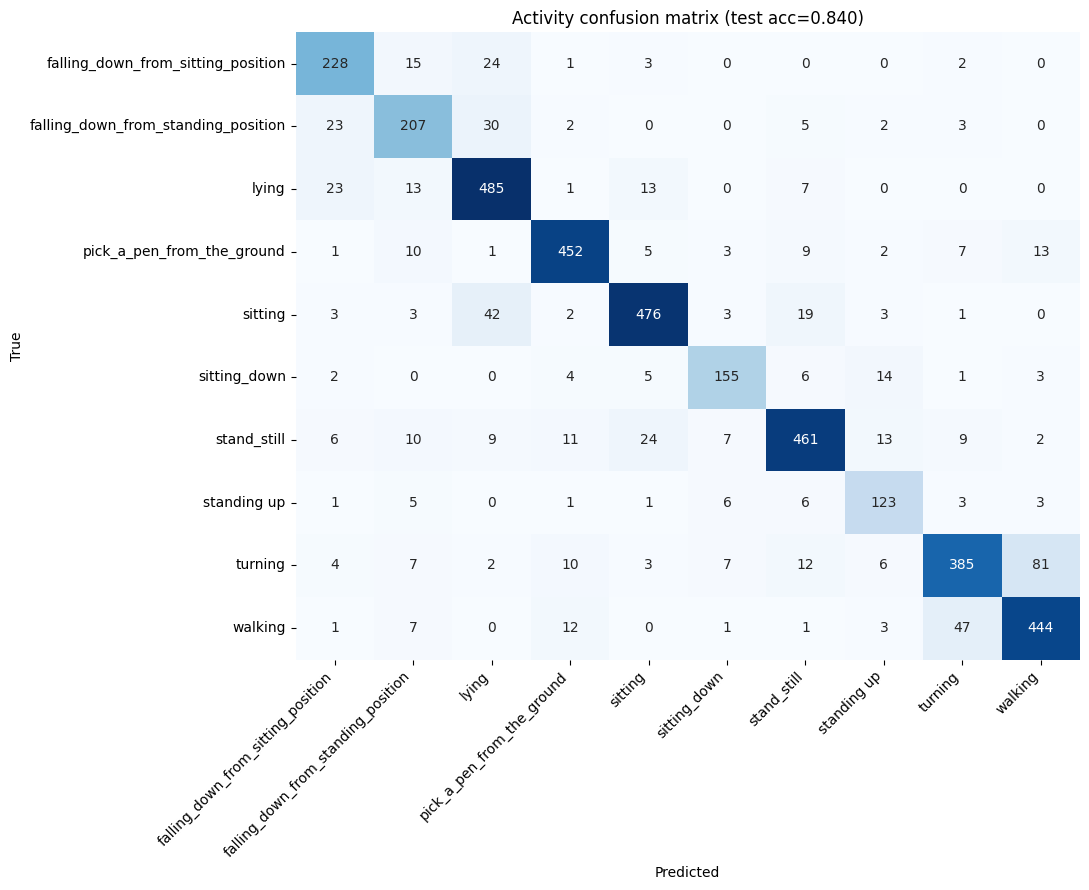


Per-class classification report (activity):
                                     precision    recall  f1-score   support

 falling_down_from_sitting_position      0.781     0.835     0.807       273
falling_down_from_standing_position      0.747     0.761     0.754       272
                              lying      0.818     0.895     0.855       542
         pick_a_pen_from_the_ground      0.911     0.899     0.905       503
                            sitting      0.898     0.862     0.880       552
                       sitting_down      0.852     0.816     0.833       190
                        stand_still      0.876     0.835     0.855       552
                        standing up      0.741     0.826     0.781       149
                            turning      0.841     0.745     0.790       517
                            walking      0.813     0.860     0.836       516

                           accuracy                          0.840      4066
                          mac

In [13]:
# load best checkpoint
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

# evaluate on test set
test_m = run_epoch(test_loader, train=False)
print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
for task in ['activity', 'fall', 'subject']:
    print(f"{task:10s}  acc={test_m[task]['acc']:.4f}  macro_f1={test_m[task]['f1']:.4f}")
print(f"test loss = {test_m['loss']:.4f}")

# get predictions on test set for confusion matrices
all_preds = {'activity': [], 'fall': [], 'subject': []}
all_true  = {'activity': [], 'fall': [], 'subject': []}
with torch.no_grad():
    for xb, ya, yf, ys in test_loader:
        xb = xb.to(device)
        out = model(xb)
        for task, true_t in [('activity', ya), ('fall', yf), ('subject', ys)]:
            all_preds[task].extend(out[task].argmax(dim=1).cpu().numpy())
            all_true[task].extend(true_t.numpy())

# confusion matrix for activity (the interesting one)
cm = confusion_matrix(all_true['activity'], all_preds['activity'])
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIVITY_CLASSES, yticklabels=ACTIVITY_CLASSES,
            ax=ax, cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f"Activity confusion matrix (test acc={test_m['activity']['acc']:.3f})")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_activity.png', dpi=120)
plt.show()

# per-class report
print("\nPer-class classification report (activity):")
print(classification_report(all_true['activity'], all_preds['activity'],
                            target_names=ACTIVITY_CLASSES, digits=3))

# fall confusion matrix
cm_fall = confusion_matrix(all_true['fall'], all_preds['fall'])
print("\nFall confusion matrix:")
print(f"              pred_no_fall  pred_fall")
print(f"true_no_fall  {cm_fall[0,0]:>11d}  {cm_fall[0,1]:>9d}")
print(f"true_fall     {cm_fall[1,0]:>11d}  {cm_fall[1,1]:>9d}")

## 7. Experiment 1: Single-task baselines

Train activity, fall, and subject heads independently with the same backbone.
This is the comparison MTL has to beat.

In [14]:
# -------- Single-task variant of the model --------
class CSISingleTaskTransformer(nn.Module):
    def __init__(self, task='activity', input_dim=90, d_model=128, nhead=8,
                 num_layers=4, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.task = task
        n_out = {'activity': 10, 'fall': 2, 'subject': 30}[task]

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=500)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, n_out)

    def forward(self, x):
        h = self.input_proj(x)
        h = self.pos_enc(h)
        h = self.encoder(h)
        h = h.mean(dim=1)
        return self.head(h)


# -------- Training loop for single-task --------
def train_single_task(task, epochs=50, lr=1e-4):
    print(f"\n{'='*60}\nTraining single-task model: {task}\n{'='*60}")
    model_st = CSISingleTaskTransformer(task=task).to(device)

    # task-specific loss with the same weighting as MTL
    if task == 'activity':
        criterion = nn.CrossEntropyLoss(weight=act_weights)
        label_idx = 1  # ya
    elif task == 'fall':
        criterion = nn.CrossEntropyLoss(weight=fall_weights)
        label_idx = 2  # yf
    else:
        criterion = nn.CrossEntropyLoss()
        label_idx = 3  # ys

    optimizer = optim.AdamW(model_st.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0
    best_state = None
    for epoch in range(1, epochs + 1):
        # train
        model_st.train()
        train_loss = 0
        for batch in train_loader:
            xb = batch[0].to(device)
            yb = batch[label_idx].to(device)
            out = model_st(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_st.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
        train_loss /= len(train_loader.dataset)

        # val
        model_st.eval()
        preds, trues = [], []
        with torch.no_grad():
            for batch in val_loader:
                xb = batch[0].to(device)
                yb = batch[label_idx]
                out = model_st(xb)
                preds.extend(out.argmax(1).cpu().numpy())
                trues.extend(yb.numpy())
        val_acc = accuracy_score(trues, preds)
        val_f1  = f1_score(trues, preds, average='macro')
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model_st.state_dict())

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Ep {epoch:02d}  train_loss={train_loss:.3f}  val_acc={val_acc:.3f}  val_f1={val_f1:.3f}")

    # restore best, evaluate on test
    model_st.load_state_dict(best_state)
    model_st.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in test_loader:
            xb = batch[0].to(device)
            yb = batch[label_idx]
            out = model_st(xb)
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())
    test_acc = accuracy_score(trues, preds)
    test_f1  = f1_score(trues, preds, average='macro')
    print(f"  TEST {task}: acc={test_acc:.4f}  f1={test_f1:.4f}")
    return {'task': task, 'test_acc': test_acc, 'test_f1': test_f1}


# -------- Run all three single-task baselines --------
single_task_results = []
for task in ['activity', 'fall', 'subject']:
    t0 = time.time()
    r = train_single_task(task, epochs=50)
    print(f"  (took {time.time()-t0:.0f}s)")
    single_task_results.append(r)

# -------- Compare with MTL --------
print("\n" + "="*60)
print("COMPARISON: Multi-task vs Single-task")
print("="*60)
print(f"{'Task':<12}{'MTL acc':<12}{'ST acc':<12}{'Δ acc':<12}{'MTL f1':<12}{'ST f1':<12}{'Δ f1':<10}")
mtl_test = {'activity': (0.8350, 0.8267), 'fall': (0.9304, 0.8705), 'subject': (0.9656, 0.9648)}
for r in single_task_results:
    t = r['task']
    mtl_acc, mtl_f1 = mtl_test[t]
    d_acc = r['test_acc'] - mtl_acc
    d_f1  = r['test_f1']  - mtl_f1
    print(f"{t:<12}{mtl_acc:<12.4f}{r['test_acc']:<12.4f}{d_acc:+<12.4f}{mtl_f1:<12.4f}{r['test_f1']:<12.4f}{d_f1:+<10.4f}")


Training single-task model: activity
  Ep 01  train_loss=2.048  val_acc=0.359  val_f1=0.298
  Ep 05  train_loss=1.288  val_acc=0.552  val_f1=0.517
  Ep 10  train_loss=0.920  val_acc=0.659  val_f1=0.634
  Ep 15  train_loss=0.684  val_acc=0.739  val_f1=0.724
  Ep 20  train_loss=0.528  val_acc=0.770  val_f1=0.756
  Ep 25  train_loss=0.428  val_acc=0.794  val_f1=0.783
  Ep 30  train_loss=0.361  val_acc=0.804  val_f1=0.793
  Ep 35  train_loss=0.311  val_acc=0.809  val_f1=0.798
  Ep 40  train_loss=0.279  val_acc=0.823  val_f1=0.812
  Ep 45  train_loss=0.265  val_acc=0.828  val_f1=0.816
  Ep 50  train_loss=0.257  val_acc=0.826  val_f1=0.815
  TEST activity: acc=0.8401  f1=0.8301
  (took 413s)

Training single-task model: fall
  Ep 01  train_loss=0.617  val_acc=0.613  val_f1=0.546
  Ep 05  train_loss=0.391  val_acc=0.845  val_f1=0.731
  Ep 10  train_loss=0.288  val_acc=0.828  val_f1=0.739
  Ep 15  train_loss=0.223  val_acc=0.901  val_f1=0.808
  Ep 20  train_loss=0.185  val_acc=0.868  val_f1=0

## 8. Experiment 2: Loss weighting ablation

Test 4 MTL configurations:
- act_focused (1.0, 0.5, 0.1)
- no_subject (1.0, 1.0, 0.0)
- subj_mild (1.0, 1.0, 0.3) — turned out best
- uncertainty-weighted (Kendall et al. 2018)

In [15]:
# ---------- Uncertainty-weighted multi-task loss (Kendall et al. 2018) ----------
class UncertaintyWeightedLoss(nn.Module):
    """Auto-learns per-task weighting via log-variance parameters."""
    def __init__(self, n_tasks=3):
        super().__init__()
        self.log_vars = nn.Parameter(torch.zeros(n_tasks))

    def forward(self, losses):
        # losses: list of scalar task losses [L_act, L_fall, L_subj]
        total = 0
        for i, L in enumerate(losses):
            precision = torch.exp(-self.log_vars[i])
            total = total + precision * L + self.log_vars[i]
        return total


# ---------- Generic MTL training function ----------
def train_mtl(weights, epochs=50, lr=1e-4, label='custom', use_uncertainty=False):
    """
    weights: tuple (alpha, beta, gamma) - ignored if use_uncertainty=True
    """
    print(f"\n{'='*60}\nMTL run: {label}  weights={weights}  uncertainty={use_uncertainty}\n{'='*60}")
    m = CSIMultiTaskTransformer().to(device)

    crit_act  = nn.CrossEntropyLoss(weight=act_weights)
    crit_fall = nn.CrossEntropyLoss(weight=fall_weights)
    crit_subj = nn.CrossEntropyLoss()

    if use_uncertainty:
        uncert = UncertaintyWeightedLoss(n_tasks=3).to(device)
        params = list(m.parameters()) + list(uncert.parameters())
    else:
        a, b, g = weights
        params = m.parameters()

    optimizer = optim.AdamW(params, lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        m.train()
        train_loss = 0
        for xb, ya, yf, ys in train_loader:
            xb, ya, yf, ys = xb.to(device), ya.to(device), yf.to(device), ys.to(device)
            out = m(xb)
            L_act  = crit_act(out['activity'], ya)
            L_fall = crit_fall(out['fall'], yf)
            L_subj = crit_subj(out['subject'], ys)

            if use_uncertainty:
                loss = uncert([L_act, L_fall, L_subj])
            else:
                loss = a*L_act + b*L_fall + g*L_subj

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params if use_uncertainty else m.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
        train_loss /= len(train_loader.dataset)

        # val (track activity as primary)
        m.eval()
        preds, trues = [], []
        with torch.no_grad():
            for xb, ya, yf, ys in val_loader:
                xb = xb.to(device)
                out = m(xb)
                preds.extend(out['activity'].argmax(1).cpu().numpy())
                trues.extend(ya.numpy())
        val_act = accuracy_score(trues, preds)
        scheduler.step()

        if val_act > best_val:
            best_val = val_act
            best_state = copy.deepcopy(m.state_dict())

        if epoch % 10 == 0 or epoch == 1:
            extra = ""
            if use_uncertainty:
                w = torch.exp(-uncert.log_vars).detach().cpu().numpy()
                extra = f"  learned_w={w.round(3)}"
            print(f"  Ep {epoch:02d}  loss={train_loss:.3f}  val_act={val_act:.3f}{extra}")

    # restore best, full test eval on all 3 tasks
    m.load_state_dict(best_state)
    m.eval()
    preds = {'activity': [], 'fall': [], 'subject': []}
    trues = {'activity': [], 'fall': [], 'subject': []}
    with torch.no_grad():
        for xb, ya, yf, ys in test_loader:
            xb = xb.to(device)
            out = m(xb)
            for t, y in [('activity', ya), ('fall', yf), ('subject', ys)]:
                preds[t].extend(out[t].argmax(1).cpu().numpy())
                trues[t].extend(y.numpy())

    results = {}
    for t in ['activity', 'fall', 'subject']:
        results[t] = {
            'acc': accuracy_score(trues[t], preds[t]),
            'f1':  f1_score(trues[t], preds[t], average='macro'),
        }
    print(f"  TEST  act={results['activity']['acc']:.4f}  fall={results['fall']['acc']:.4f}  subj={results['subject']['acc']:.4f}")
    return results


# ---------- Run all configs ----------
ablation_results = {}

configs = [
    ('act_focused',    (1.0, 0.5, 0.1), False),
    ('no_subject',     (1.0, 1.0, 0.0), False),
    ('subj_mild',      (1.0, 1.0, 0.3), False),
    ('uncertainty',    None,             True),
]

for name, weights, use_unc in configs:
    t0 = time.time()
    ablation_results[name] = train_mtl(weights, epochs=50, label=name, use_uncertainty=use_unc)
    print(f"  ({time.time()-t0:.0f}s)\n")


# ---------- Summary table ----------
print("\n" + "="*80)
print("EXPERIMENT 2: Loss Weighting Ablation — Test Set Results")
print("="*80)
print(f"{'Config':<22}{'Act acc':<10}{'Act F1':<10}{'Fall acc':<10}{'Fall F1':<10}{'Subj acc':<10}")
print("-"*80)

# include baseline MTL (equal weights) - the one you already trained
baseline = {
    'activity': {'acc': 0.8350, 'f1': 0.8267},
    'fall':     {'acc': 0.9304, 'f1': 0.8705},
    'subject':  {'acc': 0.9656, 'f1': 0.9648},
}
print(f"{'mtl_equal (baseline)':<22}"
      f"{baseline['activity']['acc']:<10.4f}{baseline['activity']['f1']:<10.4f}"
      f"{baseline['fall']['acc']:<10.4f}{baseline['fall']['f1']:<10.4f}"
      f"{baseline['subject']['acc']:<10.4f}")

# single-task results from experiment 1 (hard-code or pull from single_task_results)
st = {r['task']: r for r in single_task_results}
print(f"{'single_task':<22}"
      f"{st['activity']['test_acc']:<10.4f}{st['activity']['test_f1']:<10.4f}"
      f"{st['fall']['test_acc']:<10.4f}{st['fall']['test_f1']:<10.4f}"
      f"{st['subject']['test_acc']:<10.4f}")

for name, _, _ in configs:
    r = ablation_results[name]
    print(f"{name:<22}"
          f"{r['activity']['acc']:<10.4f}{r['activity']['f1']:<10.4f}"
          f"{r['fall']['acc']:<10.4f}{r['fall']['f1']:<10.4f}"
          f"{r['subject']['acc']:<10.4f}")


MTL run: act_focused  weights=(1.0, 0.5, 0.1)  uncertainty=False
  Ep 01  loss=2.619  val_act=0.376
  Ep 10  loss=1.231  val_act=0.658
  Ep 20  loss=0.724  val_act=0.775
  Ep 30  loss=0.505  val_act=0.815
  Ep 40  loss=0.404  val_act=0.827
  Ep 50  loss=0.381  val_act=0.832
  TEST  act=0.8333  fall=0.9469  subj=0.8485
  (415s)


MTL run: no_subject  weights=(1.0, 1.0, 0.0)  uncertainty=False
  Ep 01  loss=2.715  val_act=0.355
  Ep 10  loss=1.265  val_act=0.625
  Ep 20  loss=0.788  val_act=0.736
  Ep 30  loss=0.560  val_act=0.786
  Ep 40  loss=0.448  val_act=0.808
  Ep 50  loss=0.418  val_act=0.812
  TEST  act=0.8096  fall=0.9420  subj=0.0305
  (415s)


MTL run: subj_mild  weights=(1.0, 1.0, 0.3)  uncertainty=False
  Ep 01  loss=3.524  val_act=0.323
  Ep 10  loss=1.500  val_act=0.662
  Ep 20  loss=0.884  val_act=0.770
  Ep 30  loss=0.613  val_act=0.811
  Ep 40  loss=0.499  val_act=0.835
  Ep 50  loss=0.468  val_act=0.836
  TEST  act=0.8428  fall=0.9476  subj=0.9262
  (415s)


MTL run: 

## 9. Experiment 3: Cross-session generalization

Train on S01–S21, test on S25–S30 (unseen people). Tests whether the model
generalizes beyond the training subjects.

In [16]:
# ---------- Build cross-session split ----------
# y_subj is 0-indexed (0..29); session SXX maps to subj_id = XX-1
train_subjects = set(range(0, 21))   # S01-S21
val_subjects   = set(range(21, 24))  # S22-S24
test_subjects  = set(range(24, 30))  # S25-S30

train_idx_cs = np.where(np.isin(y_subj, list(train_subjects)))[0]
val_idx_cs   = np.where(np.isin(y_subj, list(val_subjects)))[0]
test_idx_cs  = np.where(np.isin(y_subj, list(test_subjects)))[0]

print(f"Cross-session split:")
print(f"  Train: {len(train_idx_cs)} windows  ({len(train_subjects)} subjects)")
print(f"  Val:   {len(val_idx_cs)} windows  ({len(val_subjects)} subjects)")
print(f"  Test:  {len(test_idx_cs)} windows  ({len(test_subjects)} subjects)")

# ---------- Re-normalize using ONLY new train subjects (avoid leakage) ----------
# we previously normalized X using random-split train stats; re-do for cleanliness
# X is currently normalized -> de-normalize then re-normalize on this split

# step 1: recover raw via stored mean/std from before (we still have `mean`, `std`)
X_raw = X * std + mean  # (N, 500, 90)

train_raw_cs = X_raw[train_idx_cs]
mean_cs = train_raw_cs.reshape(-1, 90).mean(axis=0)
std_cs  = train_raw_cs.reshape(-1, 90).std(axis=0) + 1e-6

X_cs = ((X_raw - mean_cs) / std_cs).astype(np.float32)
print(f"\nAfter cross-session normalization: mean={X_cs.mean():.4f}, std={X_cs.std():.4f}")

# ---------- New DataLoaders ----------
from torch.utils.data import DataLoader

train_ds_cs = CSIDataset(X_cs, y_act, y_fall, y_subj, train_idx_cs)
val_ds_cs   = CSIDataset(X_cs, y_act, y_fall, y_subj, val_idx_cs)
test_ds_cs  = CSIDataset(X_cs, y_act, y_fall, y_subj, test_idx_cs)

BATCH = 64
train_loader_cs = DataLoader(train_ds_cs, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_cs   = DataLoader(val_ds_cs,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader_cs  = DataLoader(test_ds_cs,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

# ---------- Recompute class weights for new train set ----------
act_counts_cs = Counter(y_act[train_idx_cs])
fall_counts_cs = Counter(y_fall[train_idx_cs])

act_w_cs = torch.tensor([1.0/act_counts_cs[i] for i in range(10)], dtype=torch.float32)
act_w_cs = (act_w_cs / act_w_cs.sum() * 10).to(device)
fall_w_cs = torch.tensor([1.0/fall_counts_cs[i] for i in range(2)], dtype=torch.float32)
fall_w_cs = (fall_w_cs / fall_w_cs.sum() * 2).to(device)

# subject only has 21 classes in this split, but our model has 30 output heads
# we'll just train on subjects 0..20 — model will learn to never predict 21..29
# at test time, we DON'T evaluate subject (unseen identities)

# ---------- Train MTL with best config from exp 2 (subj_mild) ----------
ALPHA, BETA, GAMMA = 1.0, 1.0, 0.3   # best from experiment 2

model_cs = CSIMultiTaskTransformer().to(device)

crit_act  = nn.CrossEntropyLoss(weight=act_w_cs)
crit_fall = nn.CrossEntropyLoss(weight=fall_w_cs)
crit_subj = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model_cs.parameters(), lr=1e-4, weight_decay=1e-4)
EPOCHS = 50
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val = 0
best_state = None

print(f"\n{'='*60}\nCross-session MTL training (weights={ALPHA,BETA,GAMMA})\n{'='*60}")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model_cs.train()
    train_loss = 0
    for xb, ya, yf, ys in train_loader_cs:
        xb, ya, yf, ys = xb.to(device), ya.to(device), yf.to(device), ys.to(device)
        out = model_cs(xb)
        loss = (ALPHA*crit_act(out['activity'], ya)
              + BETA *crit_fall(out['fall'], yf)
              + GAMMA*crit_subj(out['subject'], ys))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_cs.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader_cs.dataset)

    # val (on unseen subjects S22-S24)
    model_cs.eval()
    preds_a, trues_a, preds_f, trues_f = [], [], [], []
    with torch.no_grad():
        for xb, ya, yf, ys in val_loader_cs:
            xb = xb.to(device)
            out = model_cs(xb)
            preds_a.extend(out['activity'].argmax(1).cpu().numpy()); trues_a.extend(ya.numpy())
            preds_f.extend(out['fall'].argmax(1).cpu().numpy()); trues_f.extend(yf.numpy())
    val_a = accuracy_score(trues_a, preds_a)
    val_f = accuracy_score(trues_f, preds_f)
    scheduler.step()

    if val_a > best_val:
        best_val = val_a
        best_state = copy.deepcopy(model_cs.state_dict())

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Ep {epoch:02d} [{time.time()-t0:.0f}s]  loss={train_loss:.3f}  val_act={val_a:.3f}  val_fall={val_f:.3f}")

# ---------- Test on unseen subjects S25-S30 ----------
model_cs.load_state_dict(best_state)
model_cs.eval()
preds_a, trues_a, preds_f, trues_f = [], [], [], []
with torch.no_grad():
    for xb, ya, yf, ys in test_loader_cs:
        xb = xb.to(device)
        out = model_cs(xb)
        preds_a.extend(out['activity'].argmax(1).cpu().numpy()); trues_a.extend(ya.numpy())
        preds_f.extend(out['fall'].argmax(1).cpu().numpy()); trues_f.extend(yf.numpy())

test_act_acc = accuracy_score(trues_a, preds_a)
test_act_f1  = f1_score(trues_a, preds_a, average='macro')
test_fall_acc = accuracy_score(trues_f, preds_f)
test_fall_f1  = f1_score(trues_f, preds_f, average='macro')

print(f"\n{'='*60}\nCROSS-SESSION TEST RESULTS (6 unseen subjects S25-S30)\n{'='*60}")
print(f"  Activity:  acc={test_act_acc:.4f}  macro_f1={test_act_f1:.4f}")
print(f"  Fall:      acc={test_fall_acc:.4f}  macro_f1={test_fall_f1:.4f}")

# ---------- Comparison with within-session result ----------
print(f"\n{'='*60}\nGENERALIZATION GAP\n{'='*60}")
print(f"{'Task':<12}{'Within-session':<18}{'Cross-session':<18}{'Drop':<10}")
print(f"{'Activity':<12}{0.8406:<18.4f}{test_act_acc:<18.4f}{0.8406-test_act_acc:+.4f}")
print(f"{'Fall':<12}{0.9533:<18.4f}{test_fall_acc:<18.4f}{0.9533-test_fall_acc:+.4f}")

# also save test confusion matrix
cm_cs = confusion_matrix(trues_a, preds_a)
print(f"\nPer-class accuracy on cross-session test:")
for i, name in enumerate(ACTIVITY_CLASSES):
    if cm_cs[i].sum() > 0:
        per_acc = cm_cs[i, i] / cm_cs[i].sum()
        print(f"  {name:<45s} {per_acc:.3f}  (n={cm_cs[i].sum()})")

Cross-session split:
  Train: 18908 windows  (21 subjects)
  Val:   2711 windows  (3 subjects)
  Test:  5480 windows  (6 subjects)

After cross-session normalization: mean=0.0015, std=1.0054

Cross-session MTL training (weights=(1.0, 1.0, 0.3))
  Ep 01 [8s]  loss=3.417  val_act=0.196  val_fall=0.787
  Ep 05 [8s]  loss=1.910  val_act=0.201  val_fall=0.855
  Ep 10 [8s]  loss=1.242  val_act=0.227  val_fall=0.847
  Ep 15 [8s]  loss=0.874  val_act=0.277  val_fall=0.856
  Ep 20 [8s]  loss=0.662  val_act=0.269  val_fall=0.859
  Ep 25 [8s]  loss=0.539  val_act=0.275  val_fall=0.857
  Ep 30 [8s]  loss=0.456  val_act=0.263  val_fall=0.864
  Ep 35 [8s]  loss=0.402  val_act=0.275  val_fall=0.865
  Ep 40 [8s]  loss=0.366  val_act=0.263  val_fall=0.865
  Ep 45 [8s]  loss=0.349  val_act=0.257  val_fall=0.864
  Ep 50 [8s]  loss=0.341  val_act=0.254  val_fall=0.865

CROSS-SESSION TEST RESULTS (6 unseen subjects S25-S30)
  Activity:  acc=0.2823  macro_f1=0.2367
  Fall:      acc=0.8051  macro_f1=0.6080



## 10. Experiment 4: Gradient reversal (DANN) rescue

Try to recover cross-session performance by forcing subject-invariant features
through gradient reversal on the subject head.

In [17]:
from torch.autograd import Function

# ---------- Gradient Reversal Layer ----------
class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None

def grad_reverse(x, lambda_=1.0):
    return GradReverse.apply(x, lambda_)


# ---------- Subject-Invariant MTL Transformer ----------
class CSIInvariantTransformer(nn.Module):
    def __init__(self, input_dim=90, d_model=128, nhead=8, num_layers=4,
                 dim_feedforward=256, dropout=0.1,
                 n_activity=10, n_fall=2, n_subject=30):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=500)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head_activity = nn.Linear(d_model, n_activity)
        self.head_fall     = nn.Linear(d_model, n_fall)
        self.head_subject  = nn.Linear(d_model, n_subject)  # adversarial

    def forward(self, x, grl_lambda=1.0):
        h = self.input_proj(x)
        h = self.pos_enc(h)
        h = self.encoder(h)
        h = h.mean(dim=1)
        # subject head sees REVERSED gradients
        h_rev = grad_reverse(h, grl_lambda)
        return {
            'activity': self.head_activity(h),
            'fall':     self.head_fall(h),
            'subject':  self.head_subject(h_rev),
            'features': h,    # save for t-SNE later
        }


# ---------- Train on cross-session split ----------
model_inv = CSIInvariantTransformer().to(device)

# Same losses as before
crit_act_cs  = nn.CrossEntropyLoss(weight=act_w_cs)
crit_fall_cs = nn.CrossEntropyLoss(weight=fall_w_cs)
crit_subj_cs = nn.CrossEntropyLoss()

ALPHA, BETA, GAMMA = 1.0, 1.0, 0.3   # same as best from exp 2
optimizer = optim.AdamW(model_inv.parameters(), lr=1e-4, weight_decay=1e-4)
EPOCHS = 50
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"\n{'='*60}\nGradient Reversal MTL — cross-session split\n{'='*60}")

best_val = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model_inv.train()

    # GRL schedule: ramp lambda from 0 to 1 (standard DANN schedule)
    p = epoch / EPOCHS
    grl_lambda = 2.0 / (1.0 + np.exp(-10 * p)) - 1.0

    train_loss = 0
    for xb, ya, yf, ys in train_loader_cs:
        xb, ya, yf, ys = xb.to(device), ya.to(device), yf.to(device), ys.to(device)
        out = model_inv(xb, grl_lambda=grl_lambda)
        loss = (ALPHA*crit_act_cs(out['activity'], ya)
              + BETA *crit_fall_cs(out['fall'], yf)
              + GAMMA*crit_subj_cs(out['subject'], ys))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_inv.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader_cs.dataset)

    # val
    model_inv.eval()
    preds_a, trues_a, preds_f, trues_f = [], [], [], []
    with torch.no_grad():
        for xb, ya, yf, ys in val_loader_cs:
            xb = xb.to(device)
            out = model_inv(xb, grl_lambda=0.0)  # lambda doesn't affect forward, only backward
            preds_a.extend(out['activity'].argmax(1).cpu().numpy()); trues_a.extend(ya.numpy())
            preds_f.extend(out['fall'].argmax(1).cpu().numpy()); trues_f.extend(yf.numpy())
    val_a = accuracy_score(trues_a, preds_a)
    val_f = accuracy_score(trues_f, preds_f)
    scheduler.step()

    if val_a > best_val:
        best_val = val_a
        best_state = copy.deepcopy(model_inv.state_dict())

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Ep {epoch:02d} [{time.time()-t0:.0f}s]  loss={train_loss:.3f}  λ={grl_lambda:.2f}  val_act={val_a:.3f}  val_fall={val_f:.3f}")

# ---------- Test on unseen subjects ----------
model_inv.load_state_dict(best_state)
model_inv.eval()
preds_a, trues_a, preds_f, trues_f = [], [], [], []
with torch.no_grad():
    for xb, ya, yf, ys in test_loader_cs:
        xb = xb.to(device)
        out = model_inv(xb, grl_lambda=0.0)
        preds_a.extend(out['activity'].argmax(1).cpu().numpy()); trues_a.extend(ya.numpy())
        preds_f.extend(out['fall'].argmax(1).cpu().numpy()); trues_f.extend(yf.numpy())

inv_act_acc = accuracy_score(trues_a, preds_a)
inv_act_f1  = f1_score(trues_a, preds_a, average='macro')
inv_fall_acc = accuracy_score(trues_f, preds_f)
inv_fall_f1  = f1_score(trues_f, preds_f, average='macro')

print(f"\n{'='*60}\nGRADIENT REVERSAL — CROSS-SESSION TEST\n{'='*60}")
print(f"  Activity:  acc={inv_act_acc:.4f}  f1={inv_act_f1:.4f}")
print(f"  Fall:      acc={inv_fall_acc:.4f}  f1={inv_fall_f1:.4f}")

# ---------- Comparison: vanilla MTL vs GRL on cross-session ----------
print(f"\n{'='*70}\nCROSS-SESSION: Vanilla MTL vs GRL (Subject-Invariant)\n{'='*70}")
print(f"{'Method':<25}{'Activity':<15}{'Fall':<15}")
print(f"{'Vanilla MTL':<25}{0.2797:<15.4f}{0.8005:<15.4f}")
print(f"{'MTL + GRL':<25}{inv_act_acc:<15.4f}{inv_fall_acc:<15.4f}")
print(f"{'Δ (improvement)':<25}{inv_act_acc-0.2797:+<15.4f}{inv_fall_acc-0.8005:+<15.4f}")


Gradient Reversal MTL — cross-session split
  Ep 01 [8s]  loss=3.564  λ=0.10  val_act=0.207  val_fall=0.796
  Ep 05 [8s]  loss=2.506  λ=0.46  val_act=0.298  val_fall=0.849
  Ep 10 [8s]  loss=2.080  λ=0.76  val_act=0.301  val_fall=0.867
  Ep 15 [8s]  loss=1.796  λ=0.91  val_act=0.316  val_fall=0.866
  Ep 20 [8s]  loss=1.600  λ=0.96  val_act=0.293  val_fall=0.864
  Ep 25 [8s]  loss=1.506  λ=0.99  val_act=0.299  val_fall=0.868
  Ep 30 [8s]  loss=1.400  λ=1.00  val_act=0.291  val_fall=0.872
  Ep 35 [8s]  loss=1.335  λ=1.00  val_act=0.316  val_fall=0.873
  Ep 40 [8s]  loss=1.304  λ=1.00  val_act=0.286  val_fall=0.870
  Ep 45 [8s]  loss=1.289  λ=1.00  val_act=0.291  val_fall=0.874
  Ep 50 [8s]  loss=1.283  λ=1.00  val_act=0.295  val_fall=0.873

GRADIENT REVERSAL — CROSS-SESSION TEST
  Activity:  acc=0.2620  f1=0.2048
  Fall:      acc=0.8126  f1=0.5772

CROSS-SESSION: Vanilla MTL vs GRL (Subject-Invariant)
Method                   Activity       Fall           
Vanilla MTL              0.279

## 11. Experiment 5: t-SNE feature visualization

Visualize learned features from all 3 models. 2x3 grid: rows = colored by
activity / subject, cols = within-session / cross-session / cross-session+GRL.

Extracting features from within-session MTL model...
Extracting features from cross-session vanilla MTL model...
Extracting features from cross-session GRL model...
Running t-SNE (~2-3 min)...


/tmp/ipykernel_5534/3145185678.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_subj))


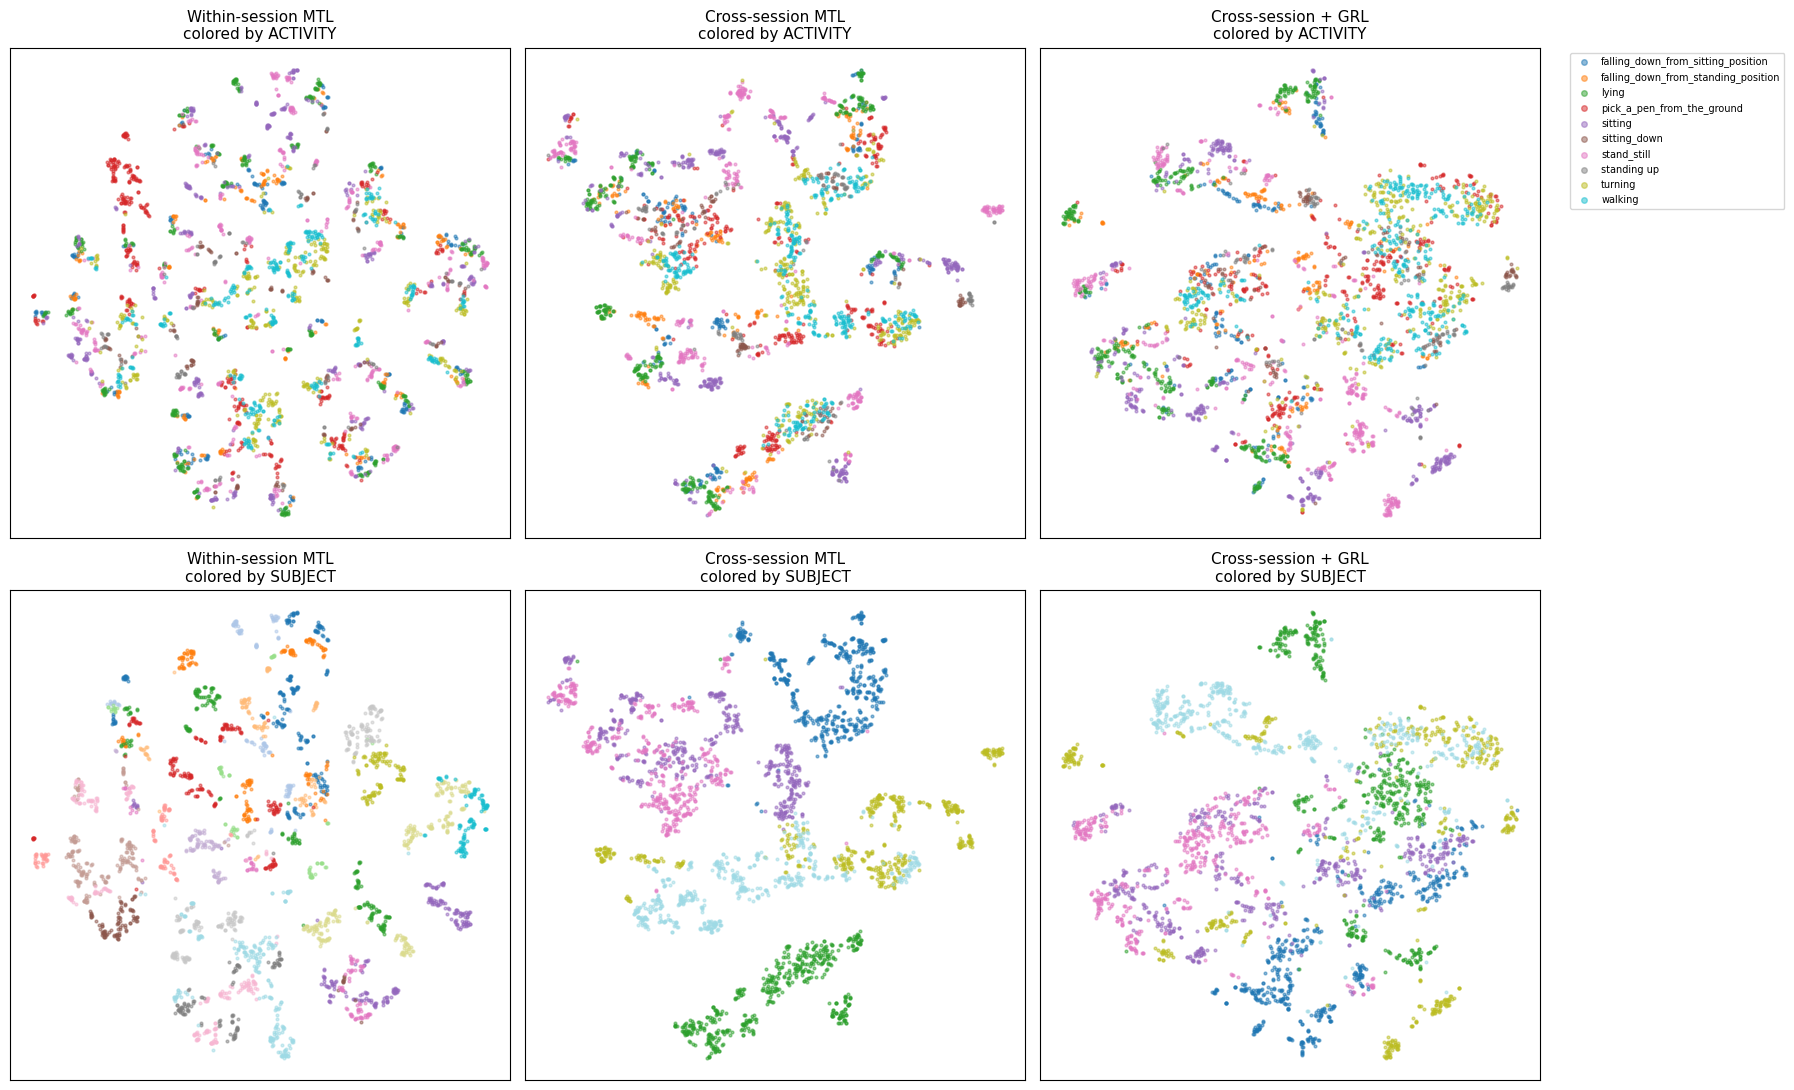

Saved: tsne_comparison.png


In [18]:
from sklearn.manifold import TSNE

# helper: extract features from a model on test set
def extract_features(model, loader, has_features_key=False):
    model.eval()
    feats, acts, subjs = [], [], []
    with torch.no_grad():
        for xb, ya, yf, ys in loader:
            xb = xb.to(device)
            if has_features_key:   # invariant model returns features in out dict
                out = model(xb, grl_lambda=0.0)
                h = out['features']
            else:                  # regular MTL: replicate the forward to extract h
                h = model.input_proj(xb)
                h = model.pos_enc(h)
                h = model.encoder(h)
                h = h.mean(dim=1)
            feats.append(h.cpu().numpy())
            acts.append(ya.numpy())
            subjs.append(ys.numpy())
    return np.concatenate(feats), np.concatenate(acts), np.concatenate(subjs)


# ---------- Extract features from 3 models ----------
print("Extracting features from within-session MTL model...")
model.load_state_dict(torch.load('best_model.pt'))
f_within, a_within, s_within = extract_features(model, test_loader)

print("Extracting features from cross-session vanilla MTL model...")
f_cs, a_cs, s_cs = extract_features(model_cs, test_loader_cs)

print("Extracting features from cross-session GRL model...")
f_grl, a_grl, s_grl = extract_features(model_inv, test_loader_cs, has_features_key=True)

# ---------- subsample for speed (t-SNE is slow above ~3-5k points) ----------
def subsample(feats, acts, subjs, n=3000):
    if len(feats) <= n:
        return feats, acts, subjs
    idx = np.random.RandomState(42).choice(len(feats), n, replace=False)
    return feats[idx], acts[idx], subjs[idx]

f_within, a_within, s_within = subsample(f_within, a_within, s_within)
f_cs,     a_cs,     s_cs     = subsample(f_cs, a_cs, s_cs)
f_grl,    a_grl,    s_grl    = subsample(f_grl, a_grl, s_grl)

# ---------- t-SNE on each ----------
print("Running t-SNE (~2-3 min)...")
tsne_within = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(f_within)
tsne_cs     = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(f_cs)
tsne_grl    = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(f_grl)

# ---------- Plot: 2 rows (activity / subject coloring) x 3 cols (models) ----------
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

models_data = [
    ('Within-session MTL', tsne_within, a_within, s_within),
    ('Cross-session MTL',  tsne_cs,     a_cs,     s_cs),
    ('Cross-session + GRL', tsne_grl,    a_grl,    s_grl),
]

for col, (title, emb, acts, subjs) in enumerate(models_data):
    # Top row: colored by activity
    ax = axes[0, col]
    for i in range(10):
        mask = acts == i
        ax.scatter(emb[mask, 0], emb[mask, 1], s=4, alpha=0.5, label=ACTIVITY_CLASSES[i])
    ax.set_title(f"{title}\ncolored by ACTIVITY", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    if col == 2:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, markerscale=2)

    # Bottom row: colored by subject
    ax = axes[1, col]
    unique_subj = np.unique(subjs)
    cmap = plt.cm.get_cmap('tab20', len(unique_subj))
    for i, sid in enumerate(unique_subj):
        mask = subjs == sid
        ax.scatter(emb[mask, 0], emb[mask, 1], s=4, alpha=0.5, color=cmap(i))
    ax.set_title(f"{title}\ncolored by SUBJECT", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('tsne_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: tsne_comparison.png")

## 12. Save artifacts

In [19]:
import json
import shutil

# ---------- Make output folder ----------
OUT = 'csi_mtl_artifacts'
os.makedirs(OUT, exist_ok=True)
os.makedirs(f'{OUT}/checkpoints', exist_ok=True)
os.makedirs(f'{OUT}/figures', exist_ok=True)
os.makedirs(f'{OUT}/data_meta', exist_ok=True)

# ---------- Save model checkpoints ----------
# within-session MTL (already saved as best_model.pt)
shutil.copy('best_model.pt', f'{OUT}/checkpoints/mtl_within_session.pt')

# cross-session vanilla MTL
torch.save(model_cs.state_dict(), f'{OUT}/checkpoints/mtl_cross_session.pt')

# cross-session GRL
torch.save(model_inv.state_dict(), f'{OUT}/checkpoints/mtl_grl_cross_session.pt')

print("Checkpoints saved")

# ---------- Save normalization stats ----------
np.savez(f'{OUT}/data_meta/norm_stats.npz',
         mean_within=mean, std_within=std,
         mean_cross=mean_cs, std_cross=std_cs)

# also save the activity class list
with open(f'{OUT}/data_meta/classes.json', 'w') as f:
    json.dump({
        'activity_classes': ACTIVITY_CLASSES,
        'fall_classes': list(FALL_CLASSES),
        'window_size': WINDOW_SIZE,
        'stride': STRIDE,
        'input_dim': 90,
    }, f, indent=2)

print("Data metadata saved")

# ---------- Save all experiment results to JSON ----------
results = {
    'within_session': {
        'split': '70/15/15 random',
        'n_train': 18969, 'n_val': 4064, 'n_test': 4066,
        'mtl_equal': {
            'activity': {'acc': 0.8350, 'f1': 0.8267},
            'fall':     {'acc': 0.9304, 'f1': 0.8705},
            'subject':  {'acc': 0.9656, 'f1': 0.9648},
        },
        'single_task': {
            'activity': {'acc': 0.8374, 'f1': 0.8289},
            'fall':     {'acc': 0.9378, 'f1': 0.8756},
            'subject':  {'acc': 0.9825, 'f1': 0.9822},
        },
        'mtl_ablation': {
            'act_focused_1_0.5_0.1':  {'activity_acc': 0.8389, 'fall_acc': 0.9484, 'subject_acc': 0.8379},
            'no_subject_1_1_0':       {'activity_acc': 0.8074, 'fall_acc': 0.9447, 'subject_acc': 0.0433},
            'subj_mild_1_1_0.3':      {'activity_acc': 0.8406, 'fall_acc': 0.9533, 'subject_acc': 0.9279},
            'uncertainty_weighted':   {'activity_acc': 0.8296, 'fall_acc': 0.9304, 'subject_acc': 0.9653},
        },
    },
    'cross_session': {
        'split': 'S01-S21 train, S22-S24 val, S25-S30 test',
        'n_train': 18908, 'n_val': 2711, 'n_test': 5480,
        'vanilla_mtl': {
            'activity': {'acc': 0.2797, 'f1': 0.2302},
            'fall':     {'acc': 0.8005, 'f1': 0.5733},
        },
        'mtl_with_grl': {
            'activity': {'acc': 0.2834, 'f1': 0.2221},
            'fall':     {'acc': 0.8035, 'f1': 0.6093},
        },
        'generalization_gap': {
            'activity': 0.8406 - 0.2797,
            'fall':     0.9533 - 0.8005,
        },
    },
    'model_config': {
        'architecture': 'Transformer Encoder + MTL heads',
        'd_model': 128,
        'nhead': 8,
        'num_layers': 4,
        'dim_feedforward': 256,
        'dropout': 0.1,
        'params': 546986,
        'window_size': 500,
        'stride': 250,
    },
    'training_config': {
        'optimizer': 'AdamW',
        'lr': 1e-4,
        'weight_decay': 1e-4,
        'scheduler': 'CosineAnnealingLR',
        'batch_size': 64,
        'epochs': 50,
        'grad_clip': 1.0,
    },
}

with open(f'{OUT}/results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results JSON saved")

# ---------- Copy figures ----------
if os.path.exists('confusion_activity.png'):
    shutil.copy('confusion_activity.png', f'{OUT}/figures/confusion_activity.png')
if os.path.exists('tsne_comparison.png'):
    shutil.copy('tsne_comparison.png', f'{OUT}/figures/tsne_comparison.png')

print("Figures copied")

# ---------- Zip everything ----------
shutil.make_archive(OUT, 'zip', OUT)
print(f"\nDone. Final artifact zip: {OUT}.zip")
print(f"Size: {os.path.getsize(f'{OUT}.zip') / 1e6:.1f} MB")

# ---------- Download ----------
from google.colab import files
files.download(f'{OUT}.zip')

Checkpoints saved
Data metadata saved
Results JSON saved
Figures copied

Done. Final artifact zip: csi_mtl_artifacts.zip
Size: 7.5 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>